# **# 📚 Project: Handwritten Digit Classification**

In [ ]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

In [ ]:
from keras.datasets import mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
x_train.shape , x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [ ]:
x_train.max()

np.uint8(255)

In [ ]:
x_train.min()

np.uint8(0)

In [ ]:
x_train = x_train/255

In [ ]:
x_test= x_test/255

In [ ]:
# Flatten
x_train = x_train.reshape(60000,784)

In [ ]:
x_test = x_test.reshape(10000,784)

In [ ]:
x_train.shape

(60000, 784)

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
from keras.utils import to_categorical

In [ ]:
y_train = to_categorical(y_train)

In [ ]:
y_test=to_categorical(y_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(784,activation='relu'))

In [ ]:
model.add(Dense(392,activation='relu'))

In [ ]:
model.add(Dense(196,activation='relu'))

In [ ]:
model.add(Dense(10,activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train, epochs = 10 , batch_size = 32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9421 - loss: 0.1909
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9726 - loss: 0.0886
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9806 - loss: 0.0649
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9848 - loss: 0.0494
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9870 - loss: 0.0420
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9900 - loss: 0.0328
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9912 - loss: 0.0292
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9909 - loss: 0.0284
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9935 - loss: 0.0223
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.9933 - loss: 0.0221


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 392)              │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 196)              │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 10)               │         1,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,006,476 (11.47 MB)

 Trainable params: 1,002,158 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,004,318 (7.65 MB)

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred = np.argmax(y_pred,axis=1)

In [ ]:
y_test=np.argmax(y_test , axis=1)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      1.00      0.98      1010
           4       0.99      0.98      0.98       982
           5       1.00      0.97      0.98       892
           6       0.97      0.99      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[ 976    0    1    0    0    0    2    0    1    0]
 [   0 1127    2    1    0    0    1    0    4    0]
 [   7    1 1008    6    1    0    3    2    4    0]
 [   0    0    1 1005    0    0    0    1    3    0]
 [   2    0    1    0  963    0    9    1    0    6]
 [   3    0    1    8    1  864    7    1    3    4]
 [   3    3    0    0    0    1  950    0    1    0]
 [   4    3    9    5    2    0    0  999    2    4]
 [   8    1    3    7    1    1    2    4  945    2]
 [   2    2    0    4    9    2    1    4    4  981]]


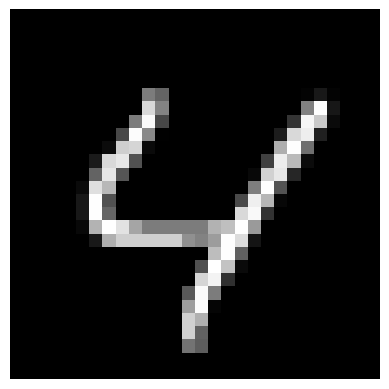

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted: 4
Actual   : 0


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

index = random.randint(0, len(x_test)-1)

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

prediction = model.predict(x_test[index].reshape(1,784))

print("Predicted:", np.argmax(prediction))
print("Actual   :", np.argmax(y_test[index]))

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving digit.png to digit.png


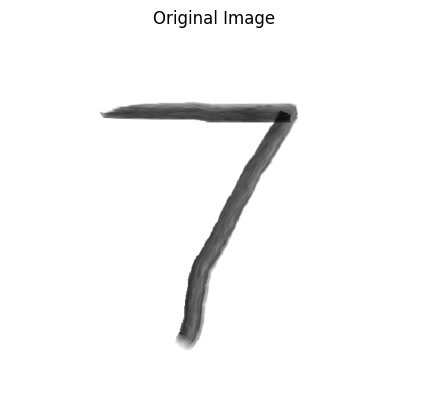

In [ ]:
img = Image.open("digit.png")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

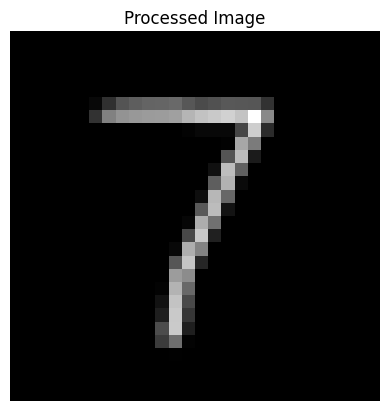

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Digit: 7


In [ ]:
# Convert to grayscale
img = img.convert("L")

# Resize to 28x28
img = img.resize((28,28))

# Invert colors
img = ImageOps.invert(img)

plt.imshow(img, cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()
img_array = np.array(img)
img_array = img_array / 255.0
img_array = img_array.reshape(1,784)
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)
print("Predicted Digit:", predicted_digit)